# MAgent2 Torch Robust MF-DSRQ Training

Train the Torch-native robust-action mean-field SRQ variant on `battle_v4` for four fixed robust epsilon values. Each epsilon gets its own run directory, reward/win plot, and final kill-rule win-rate summary.

In [1]:
from pathlib import Path
import sys


def find_repo_root(start=Path.cwd()):
    for path in (start, *start.parents):
        if (path / "discrete_action_space").is_dir() and (path / "requirements.txt").exists():
            return path
    raise RuntimeError("Could not find the SRE-DQN repo root from the current notebook directory.")


ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from discrete_action_space.mean_field_dsrq.notebook_utils import (
    mfdsrq_epsilon_config,
    notebook_mfdsrq_config,
    plot_mfdsrq_training_curves,
    print_mfdsrq_training_win_rates,
    train_mfdsrq_from_notebook,
)

NUM_EPISODES = 2000
MAX_CYCLES = 400
NUM_ENVS = 16
MAP_SIZE = 40
SEED = 42
ALGORITHM = "mf_srq_torch"
ROBUST_DISTANCE = "tv"
ROBUST_POLICY_TEMPERATURE = 0.1
DISABLE_GRAD_CLIPPING = True
SMOOTHING_WINDOW = 20
EPSILONS = [0.01, 0.1, 0.5, 1.0]

OUTPUT_ROOT = ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs" / "mf_srq_torch_epsilon_training"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

BASE_CFG = notebook_mfdsrq_config(
    target_episodes=NUM_EPISODES,
    num_envs=NUM_ENVS,
    map_size=MAP_SIZE,
    max_cycles=MAX_CYCLES,
    output_dir=OUTPUT_ROOT,
    seed=SEED,
    extra_overrides={
        "algorithm": ALGORITHM,
        "robust_policy_temperature": ROBUST_POLICY_TEMPERATURE,
        "grad_clip": None, # default is 10 but I disabled it because none of the baseline used it
        "batch_size": 256,
        "max_train_batches_per_update": None,
        "mean_field_source": "opponent",
        "epsilon_explore_mid": 0.2,
        "epsilon_explore_mid_fraction": 0.5, 
        "epsilon_explore_end": 0.05,
    },
)

MFDSRQ_TORCH_RESULTS = {}
BASE_CFG


{'algorithm': 'mf_srq_torch',
 'env_name': 'battle_v4',
 'env_backend': 'magent2',
 'map_size': 40,
 'max_cycles': 400,
 'type_prefixes': {'red': 'red_', 'blue': 'blue_'},
 'mean_field_source': 'opponent',
 'epsilon_robust_start': 0.1,
 'epsilon_robust_decay_frac': 1.0,
 'robust_policy_temperature': 0.1,
 'epsilon_explore_start': 1.0,
 'epsilon_explore_mid': 0.2,
 'epsilon_explore_mid_fraction': 0.5,
 'epsilon_explore_end': 0.05,
 'gamma': 0.95,
 'lr': 0.0001,
 'batch_size': 256,
 'buffer_capacity': 80000,
 'learning_starts': 5000,
 'target_tau': 0.005,
 'grad_clip': None,
 'target_episodes': 2000,
 'num_envs': 16,
 'seed': 42,
 'self_play_tau': 0.01,
 'max_train_batches_per_update': None,
 'output_dir': '/home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training',
 'reward_log_interval': 100,
 'save_every': 400,
 'use_gpu': True}

## Robust Epsilon 0.01

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-166.445 mean_opponent_reward=-162.588 loss=0.2104 episodes_per_sec=0.48
[mf_srq_torch] episodes=800/2000 mean_main_reward=252.606 mean_opponent_reward=223.244 loss=0.7517 episodes_per_sec=0.52
[mf_srq_torch] episodes=1200/2000 mean_main_reward=245.723 mean_opponent_reward=270.289 loss=0.7091 episodes_per_sec=0.57
[mf_srq_torch] episodes=1600/2000 mean_main_reward=244.474 mean_opponent_reward=254.903 loss=0.6527 episodes_per_sec=0.60
[mf_srq_torch] episodes=2000/2000 mean_main_reward=262.654 mean_opponent_reward=292.766 loss=0.7201 episodes_per_sec=0.61

Training complete. 2000 episodes, 329,919 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_01/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_01/battle_v4/seed42/training_stats.json
Saved training curves

{'main': 0.5035, 'opponent': 0.4645}

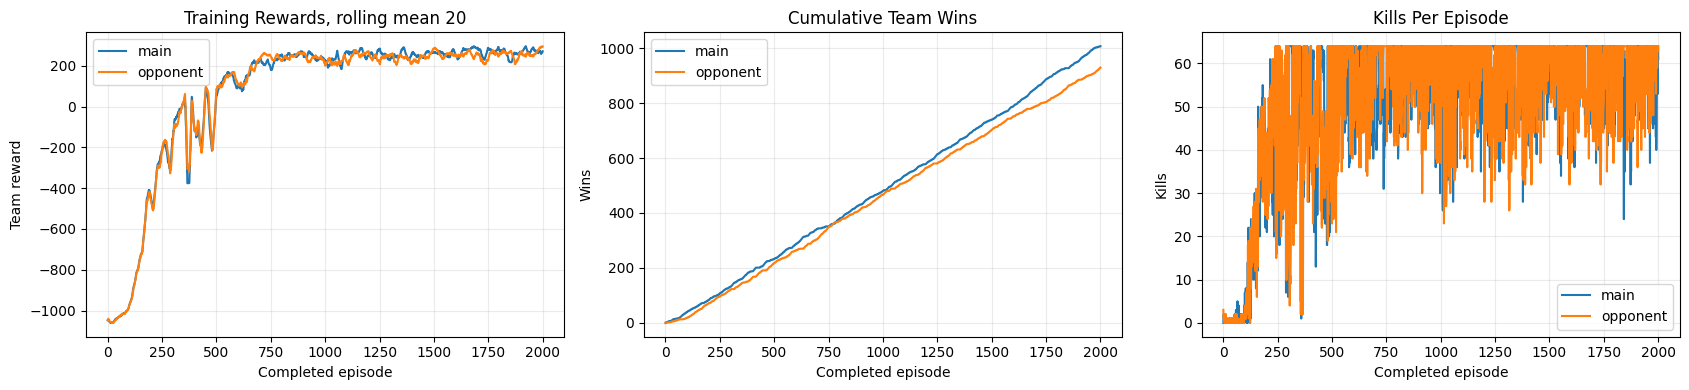

In [2]:
epsilon = 0.01
cfg_eps_0_01 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_0_01 = train_mfdsrq_from_notebook(cfg_eps_0_01)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_0_01
plot_mfdsrq_training_curves(result_eps_0_01, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_0_01)


## Robust Epsilon 0.1

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-503.976 mean_opponent_reward=-354.458 loss=0.0069 episodes_per_sec=0.37
[mf_srq_torch] episodes=800/2000 mean_main_reward=227.846 mean_opponent_reward=245.476 loss=0.3591 episodes_per_sec=0.41
[mf_srq_torch] episodes=1200/2000 mean_main_reward=256.371 mean_opponent_reward=267.636 loss=0.7651 episodes_per_sec=0.46
[mf_srq_torch] episodes=1600/2000 mean_main_reward=281.667 mean_opponent_reward=286.578 loss=0.7109 episodes_per_sec=0.48
[mf_srq_torch] episodes=2000/2000 mean_main_reward=299.228 mean_opponent_reward=271.215 loss=0.7466 episodes_per_sec=0.51

Training complete. 2000 episodes, 370,642 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_1/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_1/battle_v4/seed42/training_stats.json
Saved training curves t

{'main': 0.571, 'opponent': 0.395}

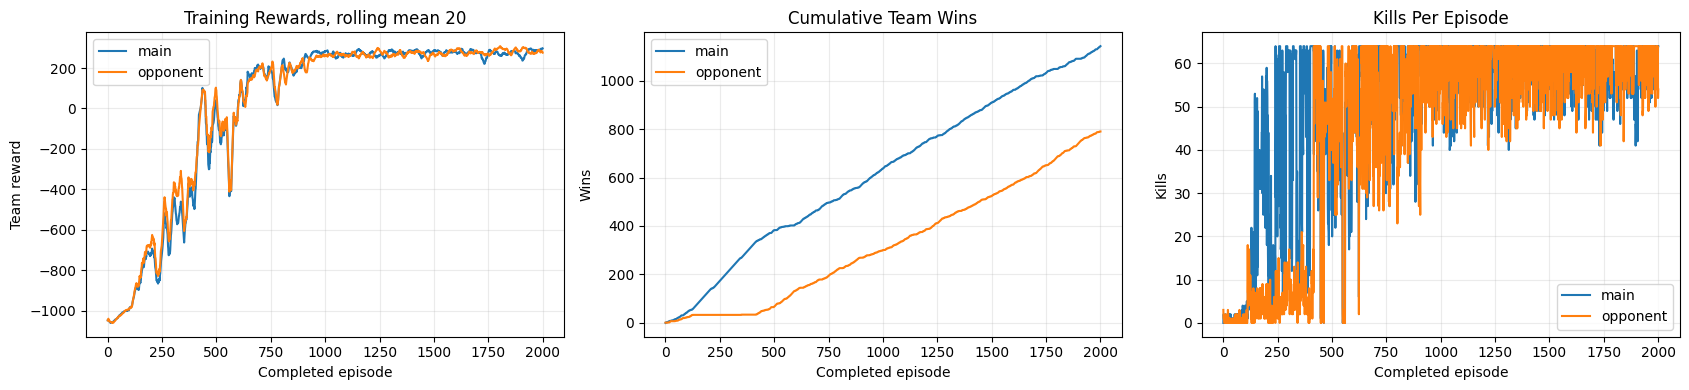

In [3]:
epsilon = 0.1
cfg_eps_0_1 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_0_1 = train_mfdsrq_from_notebook(cfg_eps_0_1)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_0_1
plot_mfdsrq_training_curves(result_eps_0_1, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_0_1)


## Robust Epsilon 0.5

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-407.599 mean_opponent_reward=-434.788 loss=0.0039 episodes_per_sec=0.28
[mf_srq_torch] episodes=800/2000 mean_main_reward=65.683 mean_opponent_reward=107.920 loss=0.0382 episodes_per_sec=0.29
[mf_srq_torch] episodes=1200/2000 mean_main_reward=260.460 mean_opponent_reward=253.445 loss=0.2056 episodes_per_sec=0.32
[mf_srq_torch] episodes=1600/2000 mean_main_reward=263.459 mean_opponent_reward=260.484 loss=0.3802 episodes_per_sec=0.35
[mf_srq_torch] episodes=2000/2000 mean_main_reward=284.430 mean_opponent_reward=269.396 loss=0.5613 episodes_per_sec=0.37

Training complete. 2000 episodes, 483,269 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_5/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_training/eps_0_5/battle_v4/seed42/training_stats.json
Saved training curves to

{'main': 0.463, 'opponent': 0.4905}

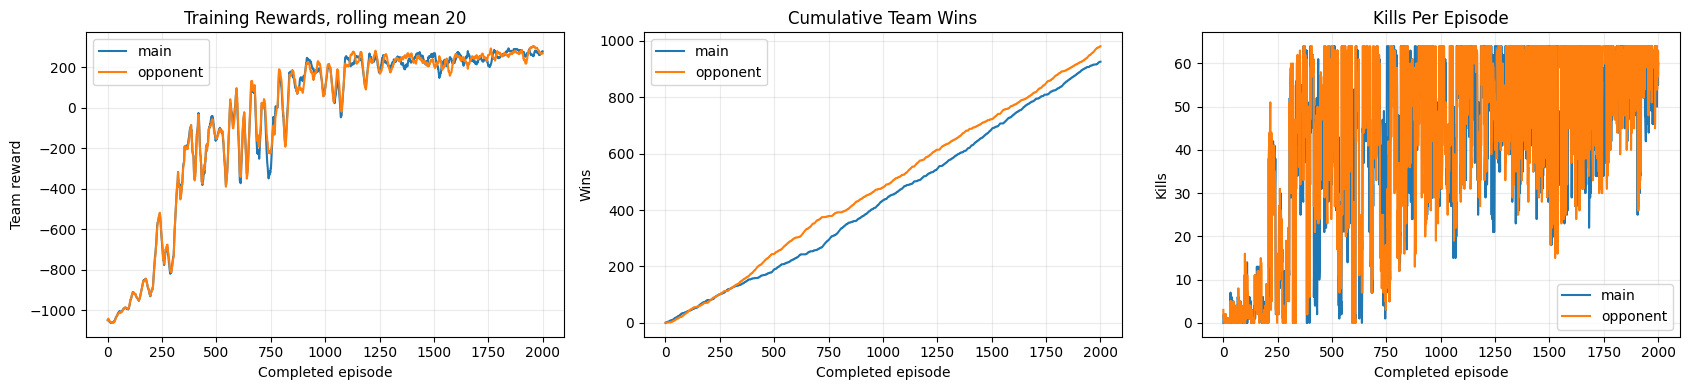

In [4]:
epsilon = 0.5
cfg_eps_0_5 = mfdsrq_epsilon_config(BASE_CFG, epsilon, OUTPUT_ROOT)
result_eps_0_5 = train_mfdsrq_from_notebook(cfg_eps_0_5)
MFDSRQ_TORCH_RESULTS[epsilon] = result_eps_0_5
plot_mfdsrq_training_curves(result_eps_0_5, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_eps_0_5)

## Decay 0.5 to 0

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-443.493 mean_opponent_reward=-412.653 loss=0.0443 episodes_per_sec=0.29
[mf_srq_torch] episodes=800/2000 mean_main_reward=149.469 mean_opponent_reward=134.867 loss=0.2121 episodes_per_sec=0.31
[mf_srq_torch] episodes=1200/2000 mean_main_reward=124.016 mean_opponent_reward=163.169 loss=0.0903 episodes_per_sec=0.35
[mf_srq_torch] episodes=1600/2000 mean_main_reward=267.162 mean_opponent_reward=255.819 loss=0.7361 episodes_per_sec=0.38
[mf_srq_torch] episodes=2000/2000 mean_main_reward=283.619 mean_opponent_reward=267.719 loss=0.5577 episodes_per_sec=0.41

Training complete. 2000 episodes, 448,443 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_5_to_0/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_5_to_0/battle_v4/seed42/training_stats.json

{'main': 0.5595, 'opponent': 0.403}

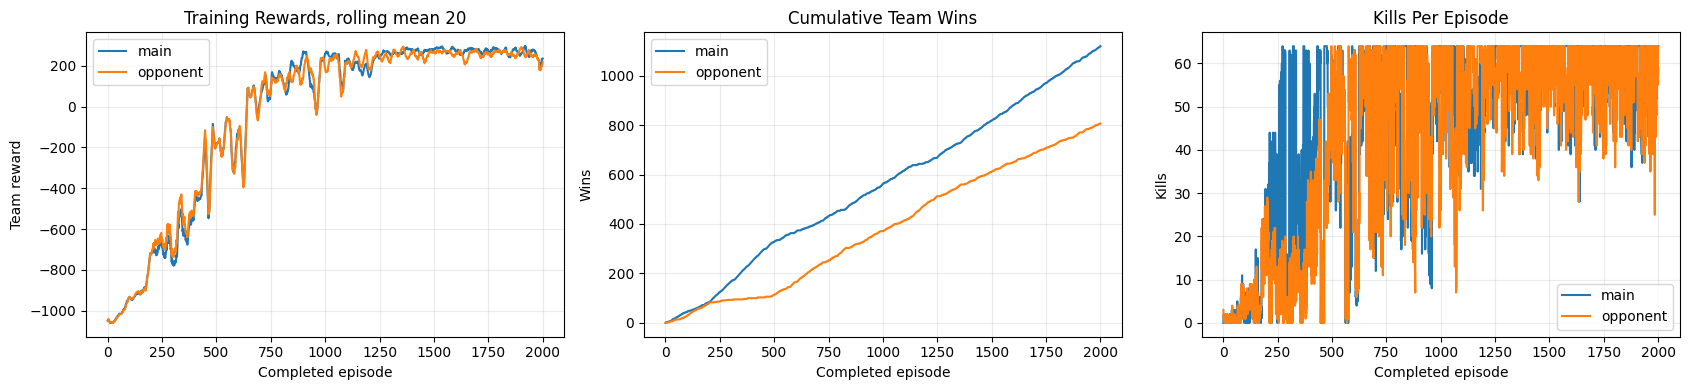

In [5]:
epsilon_start = 0.5
epsilon_end = 0.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_decay_0_5_to_0 = dict(BASE_CFG)
cfg_decay_0_5_to_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_decay_to_zero" / slug
    ),
})

result_decay_0_5_to_0 = train_mfdsrq_from_notebook(cfg_decay_0_5_to_0)
MFDSRQ_TORCH_RESULTS[("decay_to_zero", epsilon_start, epsilon_end)] = result_decay_0_5_to_0
plot_mfdsrq_training_curves(result_decay_0_5_to_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_decay_0_5_to_0)

Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-554.203 mean_opponent_reward=-443.387 loss=0.0121 episodes_per_sec=0.25
[mf_srq_torch] episodes=800/2000 mean_main_reward=62.403 mean_opponent_reward=39.510 loss=0.0553 episodes_per_sec=0.27
[mf_srq_torch] episodes=1200/2000 mean_main_reward=-46.645 mean_opponent_reward=4.267 loss=0.0025 episodes_per_sec=0.29
[mf_srq_torch] episodes=1600/2000 mean_main_reward=258.751 mean_opponent_reward=281.475 loss=0.3192 episodes_per_sec=0.32
[mf_srq_torch] episodes=2000/2000 mean_main_reward=273.652 mean_opponent_reward=283.808 loss=0.3482 episodes_per_sec=0.34

Training complete. 2000 episodes, 563,474 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_75_to_0/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_0_75_to_0/battle_v4/seed42/training_stats.json
S

{'main': 0.5605, 'opponent': 0.4065}

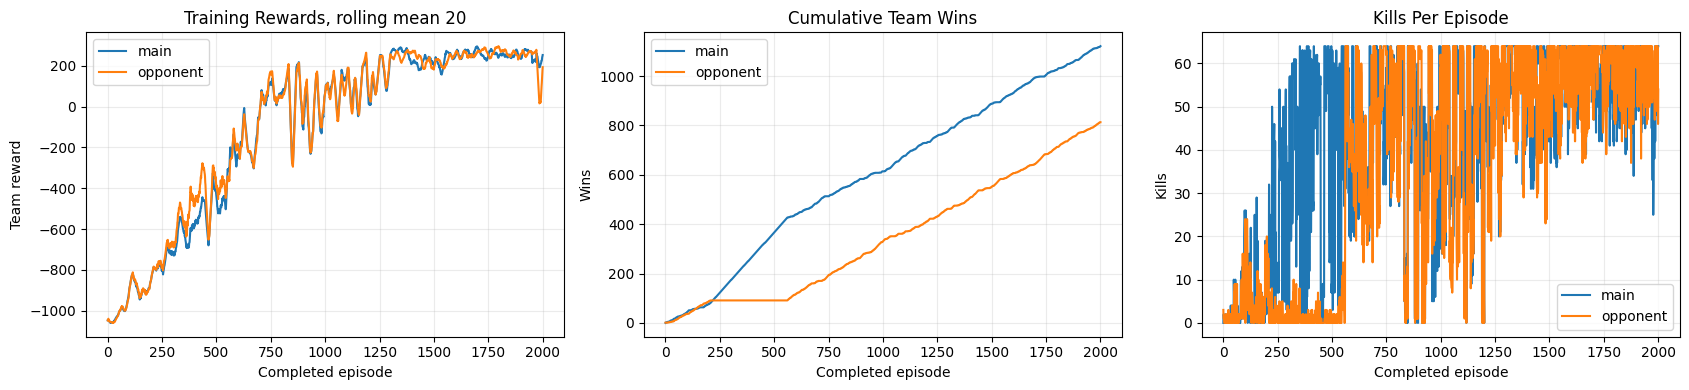

In [6]:
# Robust epsilon schedule: 0.75 -> 0
epsilon_start = 0.75
epsilon_end = 0.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_decay_0_75_to_0 = dict(BASE_CFG)
cfg_decay_0_75_to_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_decay_to_zero" / slug
    ),
})

result_decay_0_75_to_0 = train_mfdsrq_from_notebook(cfg_decay_0_75_to_0)
MFDSRQ_TORCH_RESULTS[("decay_to_zero", epsilon_start, epsilon_end)] = result_decay_0_75_to_0
plot_mfdsrq_training_curves(result_decay_0_75_to_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_decay_0_75_to_0)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-211.480 mean_opponent_reward=-218.114 loss=0.0544 episodes_per_sec=0.24
[mf_srq_torch] episodes=800/2000 mean_main_reward=216.602 mean_opponent_reward=218.973 loss=0.2096 episodes_per_sec=0.27
[mf_srq_torch] episodes=1200/2000 mean_main_reward=268.590 mean_opponent_reward=213.221 loss=0.3391 episodes_per_sec=0.29
[mf_srq_torch] episodes=1600/2000 mean_main_reward=277.566 mean_opponent_reward=263.297 loss=0.4996 episodes_per_sec=0.32
[mf_srq_torch] episodes=2000/2000 mean_main_reward=298.014 mean_opponent_reward=271.266 loss=0.6064 episodes_per_sec=0.36

Training complete. 2000 episodes, 475,647 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_1_to_0/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_decay_to_zero/start_1_to_0/battle_v4/seed42/training_stats.json
Sav

{'main': 0.466, 'opponent': 0.5015}

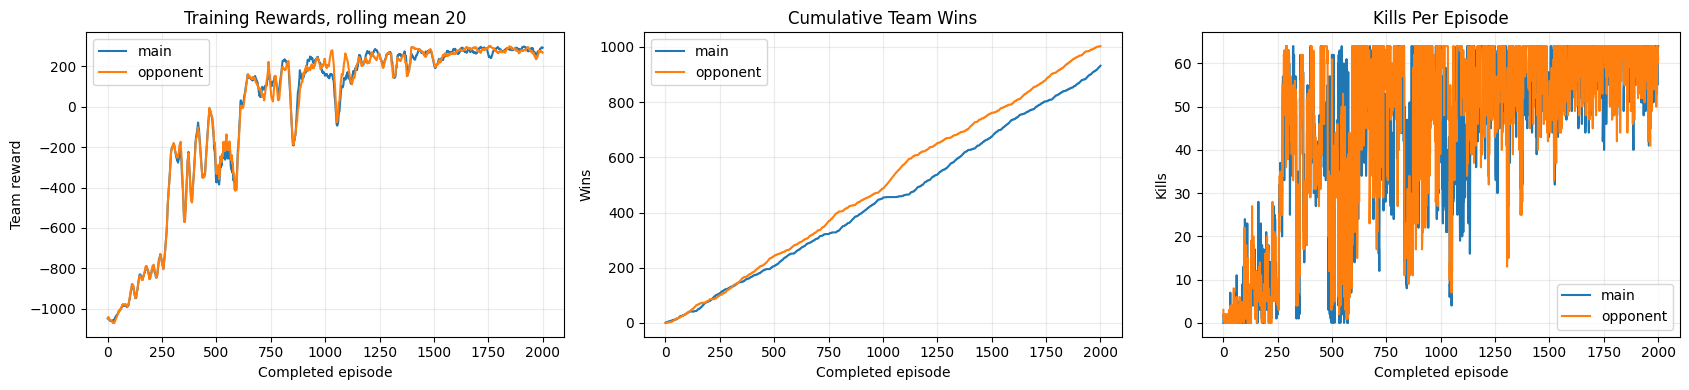

In [7]:
# Robust epsilon schedule: 1 -> 0
epsilon_start = 1.0
epsilon_end = 0.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_decay_1_0_to_0 = dict(BASE_CFG)
cfg_decay_1_0_to_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_decay_to_zero" / slug
    ),
})

result_decay_1_0_to_0 = train_mfdsrq_from_notebook(cfg_decay_1_0_to_0)
MFDSRQ_TORCH_RESULTS[("decay_to_zero", epsilon_start, epsilon_end)] = result_decay_1_0_to_0
plot_mfdsrq_training_curves(result_decay_1_0_to_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_decay_1_0_to_0)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-857.517 mean_opponent_reward=-847.911 loss=0.0118 episodes_per_sec=0.31
[mf_srq_torch] episodes=800/2000 mean_main_reward=101.781 mean_opponent_reward=70.579 loss=0.3858 episodes_per_sec=0.31
[mf_srq_torch] episodes=1200/2000 mean_main_reward=177.040 mean_opponent_reward=203.671 loss=0.3764 episodes_per_sec=0.34
[mf_srq_torch] episodes=1600/2000 mean_main_reward=243.285 mean_opponent_reward=246.257 loss=0.4230 episodes_per_sec=0.36
[mf_srq_torch] episodes=2000/2000 mean_main_reward=229.862 mean_opponent_reward=238.921 loss=0.3519 episodes_per_sec=0.37

Training complete. 2000 episodes, 477,009 env steps.
Checkpoints saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_01_to_0_5/battle_v4/seed42
Training stats saved to /home/wowthecoder/SRE-DQN/discrete_action_space/mean_field_dsrq/runs/mf_srq_torch_epsilon_ramp_up/start_0_01_to_0_5/battle_v4/seed42/training_stats.json
Saved 

{'main': 0.4265, 'opponent': 0.508}

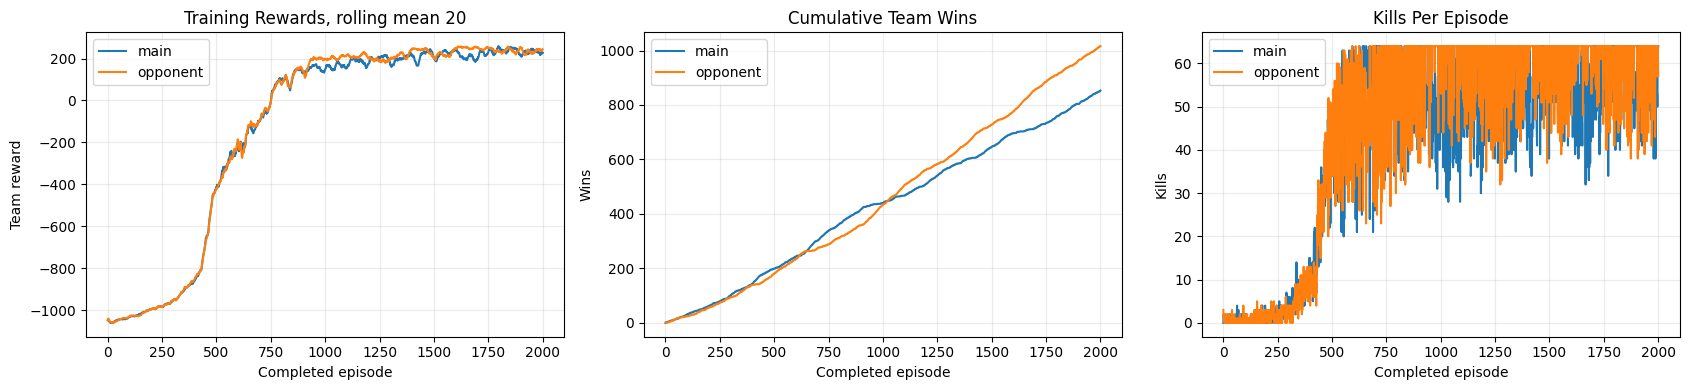

In [9]:
# Robust epsilon schedule: 0.01 -> 0.5
epsilon_start = 0.01
epsilon_end = 0.5
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_01_to_0_5 = dict(BASE_CFG)
cfg_ramp_0_01_to_0_5.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_01_to_0_5 = train_mfdsrq_from_notebook(cfg_ramp_0_01_to_0_5)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_01_to_0_5
plot_mfdsrq_training_curves(result_ramp_0_01_to_0_5, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_01_to_0_5)


In [ ]:
# Robust epsilon schedule: 0.01 -> 1
epsilon_start = 0.01
epsilon_end = 1.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_01_to_1_0 = dict(BASE_CFG)
cfg_ramp_0_01_to_1_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_01_to_1_0 = train_mfdsrq_from_notebook(cfg_ramp_0_01_to_1_0)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_01_to_1_0
plot_mfdsrq_training_curves(result_ramp_0_01_to_1_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_01_to_1_0)


Device: cuda
Starting mf_srq_torch training: 2000 episodes, 16 envs, max_cycles=400


MF-DSRQ episodes:   0%|                                                                        | 0/2000 [00:00…

[mf_srq_torch] episodes=400/2000 mean_main_reward=-873.414 mean_opponent_reward=-877.989 loss=0.0073 episodes_per_sec=0.46


In [ ]:
# Robust epsilon schedule: 0.1 -> 0.5
epsilon_start = 0.1
epsilon_end = 0.5
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_1_to_0_5 = dict(BASE_CFG)
cfg_ramp_0_1_to_0_5.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_1_to_0_5 = train_mfdsrq_from_notebook(cfg_ramp_0_1_to_0_5)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_1_to_0_5
plot_mfdsrq_training_curves(result_ramp_0_1_to_0_5, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_1_to_0_5)


In [ ]:
# Robust epsilon schedule: 0.1 -> 1
epsilon_start = 0.1
epsilon_end = 1.0
slug = f"start_{epsilon_start:g}_to_{epsilon_end:g}".replace(".", "_")

cfg_ramp_0_1_to_1_0 = dict(BASE_CFG)
cfg_ramp_0_1_to_1_0.update({
    "epsilon_robust_start": epsilon_start,
    "epsilon_robust_end": epsilon_end,
    "epsilon_robust_decay_frac": 1.0,
    "output_dir": str(
        ROOT / "discrete_action_space" / "mean_field_dsrq" / "runs"
        / "mf_srq_torch_epsilon_ramp_up" / slug
    ),
})

result_ramp_0_1_to_1_0 = train_mfdsrq_from_notebook(cfg_ramp_0_1_to_1_0)
MFDSRQ_TORCH_RESULTS[("ramp_up", epsilon_start, epsilon_end)] = result_ramp_0_1_to_1_0
plot_mfdsrq_training_curves(result_ramp_0_1_to_1_0, smoothing_window=SMOOTHING_WINDOW)
print_mfdsrq_training_win_rates(result_ramp_0_1_to_1_0)
